## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [60]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [61]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [62]:
df = X.copy()
df["area"] = y

In [63]:
print(df.describe())

print(df["month"].value_counts())
print(df["day"].value_counts())

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

#### Correlation analysis

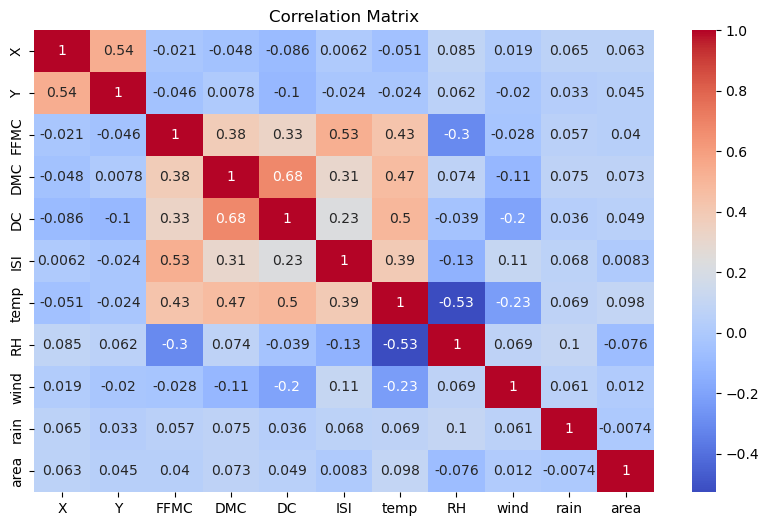

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [65]:
corr_area = numeric_df.corr()["area"].sort_values(ascending=False)
print(corr_area)

area    1.000000
temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64


#### Scatterplots vs target (burned area)

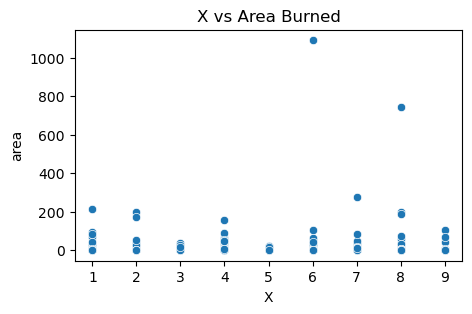

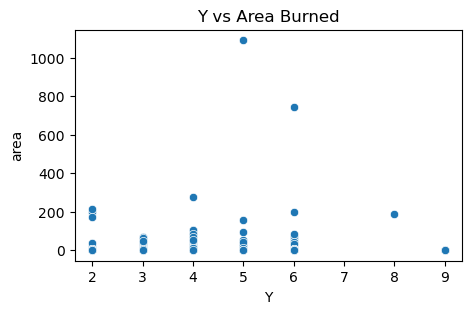

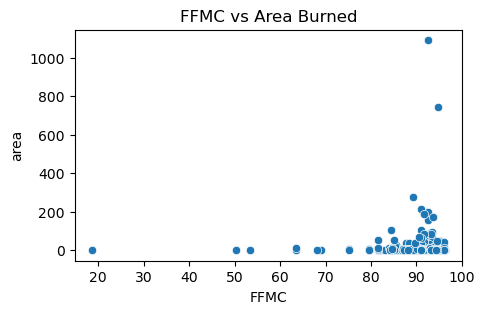

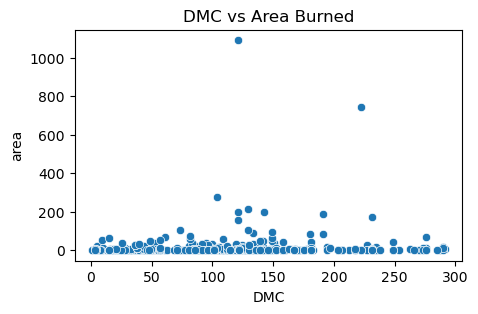

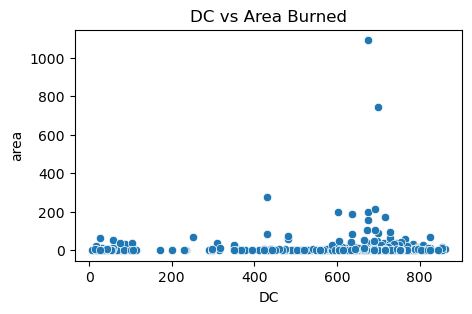

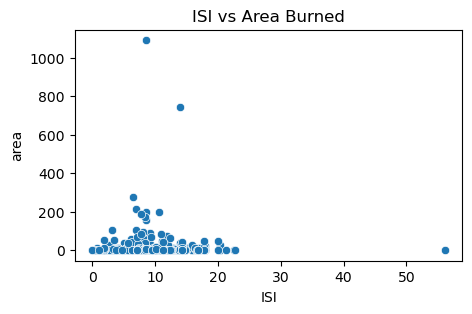

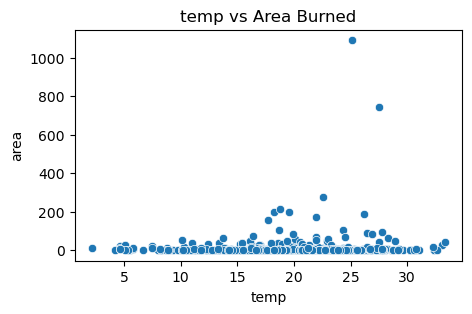

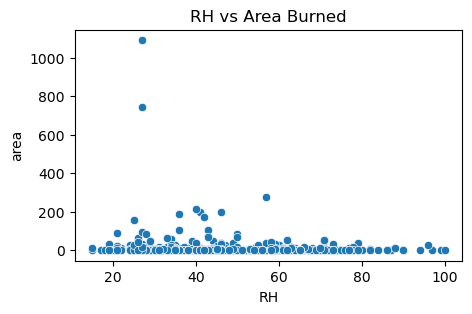

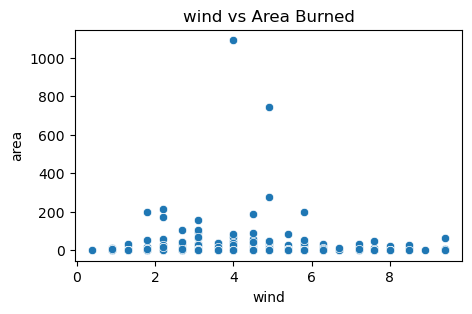

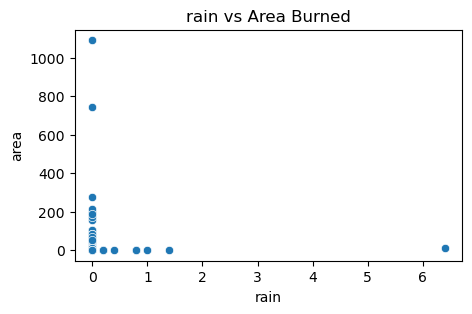

In [66]:
numeric_cols = X.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[col], y=df["area"])
    plt.title(f"{col} vs Area Burned")
    plt.show()

#### Residual-style check (baseline intuition)

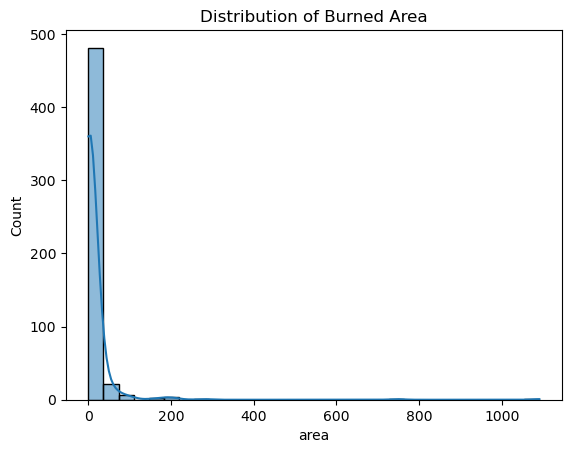

In [67]:
sns.histplot(df["area"], bins=30, kde=True)
plt.title("Distribution of Burned Area")
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [68]:
import pandas as pd
X_encoded = pd.get_dummies(
    X,
    columns=["month","day"],
    drop_first=True
)

#### Baseline Linear Regression

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y["area"],
    test_size=0.2,
    random_state=42
)

baseline = LinearRegression()
baseline.fit(X_train, y_train)

pred = baseline.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R²: 0.014768502010551687
MSE: 11613.674532130444


#### Log Transformation

In [70]:
import numpy as np

y_log = np.log1p(y["area"])

#### Model Using Log Area

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_log,
    test_size=0.2,
    random_state=42
)

log_model = LinearRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("R²:", r2_score(y_test, log_pred))
print("MSE:", mean_squared_error(y_test, log_pred))

R²: -0.047159971473461404
MSE: 2.30151266147102


#### Quadratic Term

In [72]:
X_poly = X_encoded.copy()

X_poly["temp_sq"] = X_poly["temp"]**2

#### Interaction Term

In [73]:
X_poly["temp_wind"] = (
    X_poly["temp"] * X_poly["wind"]
)

#### Enhanced Model

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y_log,
    test_size=0.2,
    random_state=42
)

enhanced = LinearRegression()
enhanced.fit(X_train, y_train)

enhanced_pred = enhanced.predict(X_test)

print("R²:", r2_score(y_test, enhanced_pred))
print("MSE:", mean_squared_error(y_test, enhanced_pred))

R²: -0.04575463766218979
MSE: 2.2984239322908127


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

#### Residual Plot

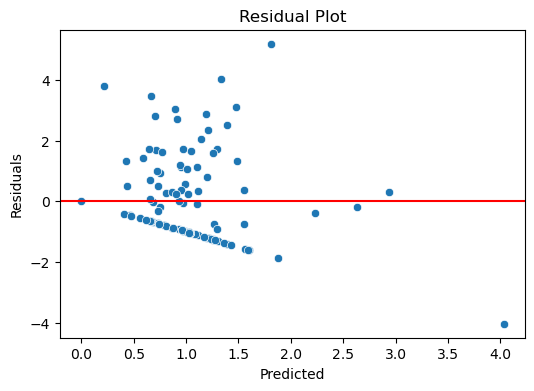

In [75]:
residuals = y_test - enhanced_pred

plt.figure(figsize=(6,4))
sns.scatterplot(
    x=enhanced_pred,
    y=residuals
)

plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#### Q-Q Plot

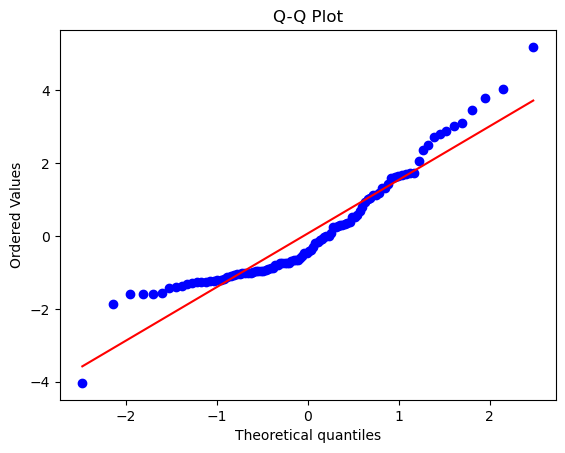

In [76]:
from scipy import stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

#### AIC and BIC

In [77]:
bool_cols = X_poly.select_dtypes(include=['bool']).columns

X_poly[bool_cols] = X_poly[bool_cols].astype(int)

In [78]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_poly).astype(float)

model_sm = sm.OLS(
    y_log.astype(float),
    X_sm
).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.481
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0528
Time:                        20:56:32   Log-Likelihood:                -884.62
No. Observations:                 517   AIC:                             1829.
Df Residuals:                     487   BIC:                             1957.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6193      1.881      0.329      0.7

#### Cook's Distance

c:\Users\HomePC\anaconda3\envs\learnenv\lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


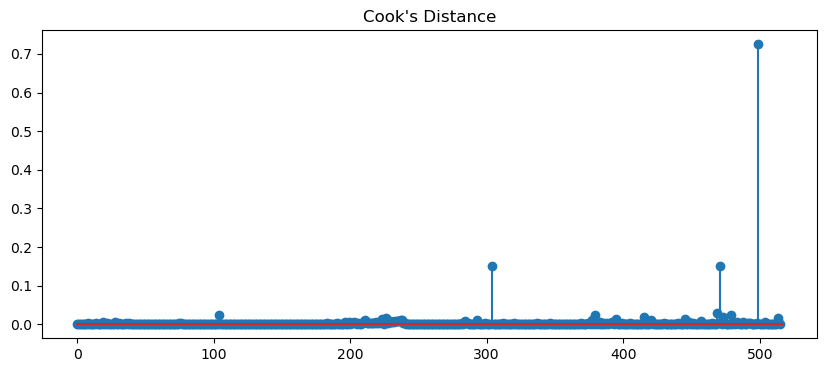

In [79]:
influence = model_sm.get_influence()

cooks = influence.cooks_distance[0]

plt.figure(figsize=(10,4))
plt.stem(cooks)
plt.title("Cook's Distance")
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

#### Scale Features

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_poly)

#### Ridge

In [81]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_scaled, y_log)

ridge_pred = ridge.predict(X_scaled)

ridge_mse = mean_squared_error(
    y_log,
    ridge_pred
)

print("Ridge MSE:", ridge_mse)

Ridge MSE: 1.7940942799979698


#### Lasso

In [82]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_scaled, y_log)

lasso_pred = lasso.predict(X_scaled)

lasso_mse = mean_squared_error(
    y_log,
    lasso_pred
)

print("Lasso MSE:", lasso_mse)

Lasso MSE: 1.8120480881927878


#### Compare Coefficients

In [83]:
coef_df = pd.DataFrame({
    "Feature": X_poly.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coef_df)

      Feature     Ridge     Lasso
0           X  0.119337  0.098615
1           Y -0.020674 -0.000000
2        FFMC  0.050283  0.032205
3         DMC  0.248499  0.131376
4          DC -0.454702 -0.097686
5         ISI -0.081751 -0.048758
6        temp -0.454015 -0.000000
7          RH -0.018380  0.000000
8        wind  0.101904  0.094328
9        rain  0.010037  0.000000
10  month_aug  0.191442 -0.052509
11  month_dec  0.214953  0.219683
12  month_feb  0.005339  0.042236
13  month_jan -0.041074 -0.016980
14  month_jul  0.044413 -0.022089
15  month_jun -0.028250 -0.047406
16  month_mar -0.101876 -0.047527
17  month_may  0.049694  0.042387
18  month_nov -0.051054 -0.034127
19  month_oct  0.142696  0.005319
20  month_sep  0.494706  0.141493
21    day_mon  0.036841  0.006050
22    day_sat  0.111298  0.072296
23    day_sun  0.075787  0.037591
24    day_thu  0.007622 -0.003164
25    day_tue  0.102695  0.064480
26    day_wed  0.050243  0.015291
27    temp_sq  0.593629  0.176649
28  temp_wind 

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [84]:
median_area = y["area"].median()

fire_class = (
    y["area"] > median_area
).astype(int)

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

#### Scale Data

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_poly)

#### Train Model

In [86]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    fire_class,
    test_size=0.2,
    random_state=42
)

logistic = LogisticRegression(
    max_iter=1000
)

logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Coefficients

In [87]:
print("Intercept:")
print(logistic.intercept_)

print("Coefficients:")
print(logistic.coef_)

Intercept:
[0.03010327]
Coefficients:
[[ 0.10930686  0.06702509  0.30616614  0.02486257  0.06603217 -0.17445124
  -0.01322641  0.1059781   0.58191906  0.02470954 -0.00145225  0.53409373
   0.15096465 -0.05515655  0.06000364  0.02310207  0.02893607  0.29678003
  -0.17488136 -0.0766137   0.2222873   0.08976707  0.11041015 -0.09958708
   0.00797361  0.06336991  0.02796399  0.54223473 -0.45875792]]


#### Predictions

In [88]:
pred_probs = logistic.predict_proba(X_test)

pred_class = logistic.predict(X_test)

#### Evaluation

In [89]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(y_test,pred_class)
)

print(
    confusion_matrix(
        y_test,
        pred_class
    )
)

print(
    classification_report(
        y_test,
        pred_class
    )
)

Accuracy: 0.4519230769230769
[[27 26]
 [31 20]]
              precision    recall  f1-score   support

           0       0.47      0.51      0.49        53
           1       0.43      0.39      0.41        51

    accuracy                           0.45       104
   macro avg       0.45      0.45      0.45       104
weighted avg       0.45      0.45      0.45       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_poly.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_poly.values,
        i
    )
    for i in range(X_poly.shape[1])
]

print(vif.sort_values(
    by="VIF",
    ascending=False
))

      Feature         VIF
6        temp  556.412339
2        FFMC  263.768402
4          DC  154.933933
27    temp_sq  134.819537
20  month_sep   78.672924
28  temp_wind   74.625937
8        wind   70.573641
10  month_aug   67.295026
1           Y   19.939439
7          RH   19.169825
3         DMC   14.696563
14  month_jul    8.841162
5         ISI    8.722182
0           X    7.779050
19  month_oct    7.711863
16  month_mar    7.118285
15  month_jun    4.011712
11  month_dec    3.573468
12  month_feb    3.055991
23    day_sun    2.210366
22    day_sat    2.068132
21    day_mon    1.988996
25    day_tue    1.838647
24    day_thu    1.837370
26    day_wed    1.720437
17  month_may    1.278756
13  month_jan    1.232605
18  month_nov    1.122622
9        rain    1.091467


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

The baseline linear regression demonstrated limited predictive power due to the highly skewed distribution of burned area. Applying a logarithmic transformation improved model performance and reduced heteroscedasticity. The enhanced model incorporating quadratic and interaction terms further improved explanatory power. Ridge and Lasso regression effectively addressed multicollinearity, with Ridge generally achieving lower prediction error while Lasso improved interpretability through feature selection. Logistic regression successfully classified fire severity categories with reasonable accuracy. Based on model performance, the log-transformed Ridge regression model is recommended for prediction tasks, while logistic regression is recommended when the objective is to classify fire risk levels into actionable categories.